In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


In [3]:
df = pd.read_csv("../data/processed/online_retail_final.csv")

df.head()



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth,InvoiceYear,InvoiceDay,InvoiceHour,IsWeekend,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,2010,Wednesday,8,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,8,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,2010,Wednesday,8,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,8,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,8,False,20.34


In [4]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])


Create Invoice Month



In [5]:
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth,InvoiceYear,InvoiceDay,InvoiceHour,IsWeekend,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,2010,Wednesday,8,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,8,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,2010,Wednesday,8,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,8,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,8,False,20.34


Monthly Active Customers

<Axes: title={'center': 'Monthly Active Customers'}, xlabel='InvoiceMonth'>

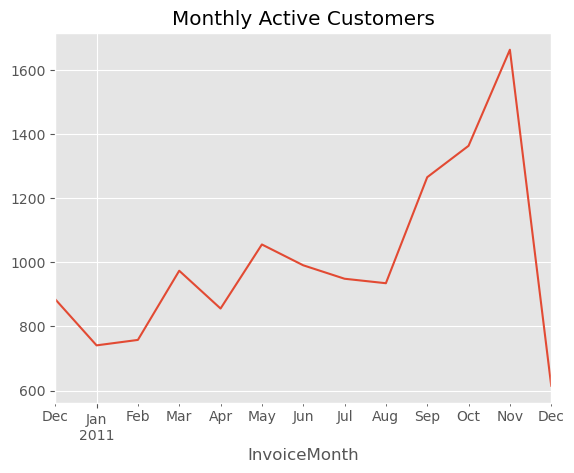

In [7]:
monthly_customers = (
    df.groupby("InvoiceMonth")["CustomerID"]
      .nunique()
)

monthly_customers.plot(title="Monthly Active Customers")



Calculate Repeat Customers

In [8]:
repeat_customers = (
    df.groupby("CustomerID")["InvoiceNo"]
      .nunique()
)

repeat_customers.head()

CustomerID
12346    1
12347    7
12348    4
12349    1
12350    1
Name: InvoiceNo, dtype: int64

Count Repeat Customers

In [9]:
repeat_count = (repeat_customers > 1).sum()

total_customers = repeat_customers.count()

print("Repeat Customers:", repeat_count)
print("Total Customers:", total_customers)

Repeat Customers: 2845
Total Customers: 4338


Calculate Retention Rate

Formula

Retention Rate=Repeat Customers/Total Customers×100

In [10]:
retention_rate = (repeat_count / total_customers) * 100

print(f"Retention Rate: {retention_rate:.2f}%")

Retention Rate: 65.58%


Calculate Churn Rate

Formula

Churn Rate=100−Retention Rate

In [11]:
churn_rate = 100 - retention_rate

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 34.42%


Create KPI Table

In [12]:
kpi = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Repeat Customers",
        "Retention Rate",
        "Churn Rate"
    ],
    "Value": [
        total_customers,
        repeat_count,
        round(retention_rate,2),
        round(churn_rate,2)
    ]
})

kpi

,Metric,Value
0,Total Customers,4338.00
1,Repeat Customers,2845.00
2,Retention Rate,65.58
3,Churn Rate,34.42


KPI Bar Chart

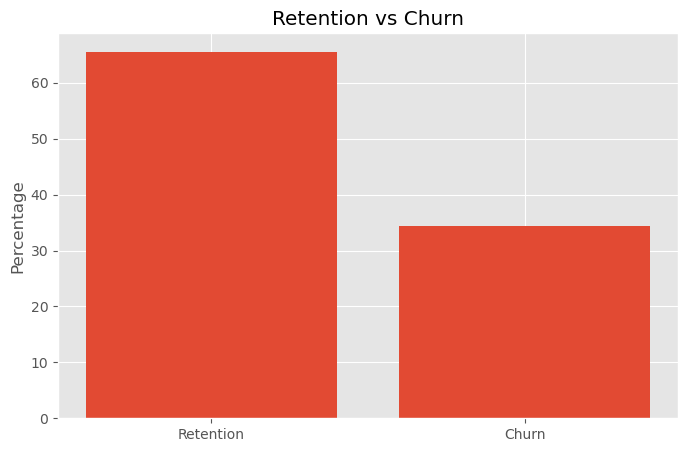

In [13]:
plt.figure(figsize=(8,5))

plt.bar(
    ["Retention","Churn"],
    [retention_rate,churn_rate]
)

plt.title("Retention vs Churn")

plt.ylabel("Percentage")

plt.show()

Monthly Revenue

In [14]:
monthly_revenue = (
    df.groupby("InvoiceMonth")["TotalPrice"]
      .sum()
)

monthly_revenue

InvoiceMonth
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: TotalPrice, dtype: float64

Revenue Trend

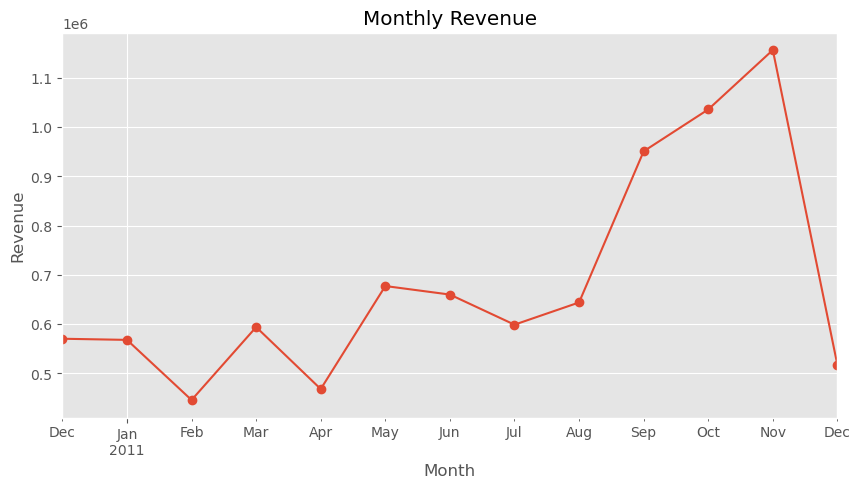

In [15]:
plt.figure(figsize=(10,5))

monthly_revenue.plot(marker="o")

plt.title("Monthly Revenue")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

Average Orders per Customer

In [16]:
avg_orders = (
    df.groupby("CustomerID")["InvoiceNo"]
      .nunique()
      .mean()
)

print(avg_orders)

4.272014753342554


Save KPI Dataset

In [17]:
kpi.to_csv(
    "../data/processed/retention_metrics.csv",
    index=False
)

# Customer Retention Analysis

## Key Findings

1. Retention Rate measures the percentage of customers who returned to make another purchase.

2. Churn Rate measures the percentage of customers who did not return.

3. Higher retention generally indicates stronger customer satisfaction and loyalty.

4. Monthly active customer trends help identify periods of business growth or decline.

5. Businesses should focus on retaining high-value customers to improve long-term revenue and profitability.